# Demostración Final — Limpieza de Audio con FFT

Este notebook reúne todo el proyecto en acción. Veremos tres demostraciones completas, de menor a mayor complejidad:

1. **Prueba con voz real** — grabamos nuestra propia voz, le inyectamos un pitido artificial y lo eliminamos con un filtro Notch.
2. **DFT manual (método arcaico)** — implementamos la transformada de Fourier paso a paso, sin librerías, para entender cómo funciona por dentro. También medimos cuánto más lento es comparado con la FFT.
3. **Filtros Pasa-Bajas y Pasa-Altas** — demostramos los otros dos tipos de filtros con señales sintéticas y gráficas comparativas.

---

## Demo 1: Prueba real con audio creado por los integrantes

El flujo de esta prueba es:
1. Cargar nuestra grabación de voz desde `data/raw/voz.wav`.
2. Inyectarle un pitido molesto de **800 Hz** para simular interferencia.
3. Guardar el audio arruinado para tener el "antes".
4. Limpiar la señal con un filtro **Notch en 800 Hz** usando la FFT.
5. Guardar el audio rescatado para tener el "después".

In [1]:
import sys
from pathlib import Path
import numpy as np
import soundfile as sf
from scipy.fft import fft, ifft

# 1. Importamos tus módulos
sys.path.append("..")
from src.audio_loader import load_audio
from src.filters import apply_notch_mask

# 2. Cargar tu voz real
RUTA_VOZ = Path("../data/raw/voz.wav")
senal_ideal, sample_rate = load_audio(RUTA_VOZ)

# 3. SInyectar ruido
t = np.arange(len(senal_ideal)) / sample_rate
pitido_molesto = 0.5 * np.sin(2 * np.pi * 800 * t)
senal_arruinada = senal_ideal + pitido_molesto

# Guardamos el audio arruinado para la presentación
sf.write("../data/processed/demo1_voz_arruinada.wav", senal_arruinada, sample_rate)

# 4. RESCATE: Limpiamos con la Transformada de Fourier
espectro_arruinado = fft(senal_arruinada)
# Aplicamos la máscara específicamente en 800 Hz
espectro_limpio = apply_notch_mask(espectro_arruinado, center_hz=800.0, bandwidth_hz=10.0, sample_rate=sample_rate)
# Reconstrucción
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
sf.write("../data/processed/demo1_voz_rescatada.wav", senal_rescatada, sample_rate)

print("¡Audio arruinado y rescatado con éxito!")
print("Revisa la carpeta 'data/processed/' para escuchar el resultado.")

¡Audio arruinado y rescatado con éxito!
Revisa la carpeta 'data/processed/' para escuchar el resultado.


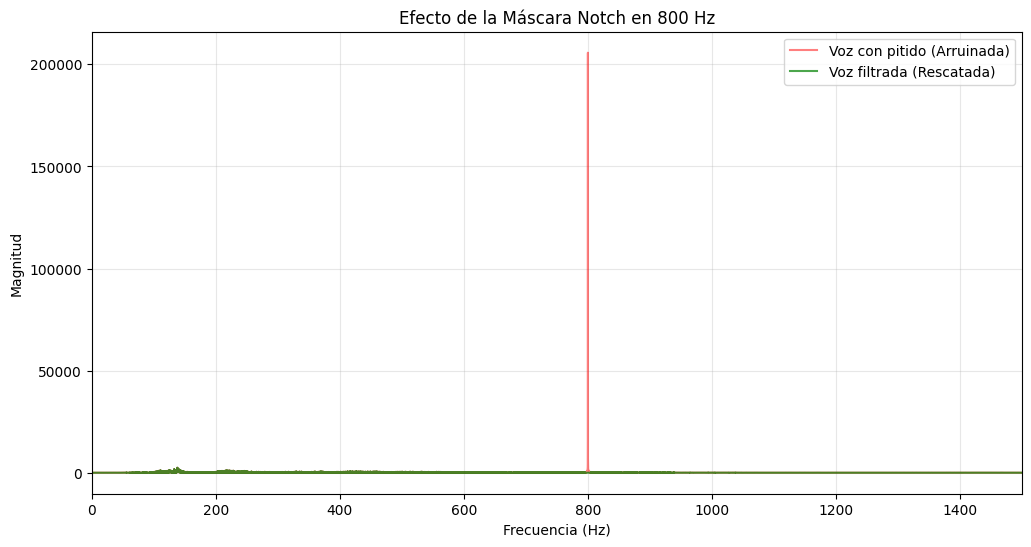

In [2]:
import matplotlib.pyplot as plt
from scipy.fft import fftfreq

# Preparamos los datos para graficar
N = len(senal_arruinada)
frecuencias = fftfreq(N, 1 / sample_rate)
mitad = N // 2

# Magnitudes
mag_arruinada = np.abs(fft(senal_arruinada)[:mitad])
mag_rescatada = np.abs(fft(senal_rescatada)[:mitad])

plt.figure(figsize=(12, 6))
plt.plot(frecuencias[:mitad], mag_arruinada, color='red', alpha=0.5, label='Voz con pitido (Arruinada)')
plt.plot(frecuencias[:mitad], mag_rescatada, color='green', alpha=0.7, label='Voz filtrada (Rescatada)')

plt.title("Efecto de la Máscara Notch en 800 Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 1500)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### ¿Qué muestra la gráfica?

La gráfica compara los espectros de frecuencia de ambas versiones del audio:

- **Línea roja** → voz con el pitido de 800 Hz. Deberías ver un pico pronunciado en esa frecuencia.
- **Línea verde** → voz filtrada. El pico de 800 Hz desaparece, confirmando que el filtro Notch funcionó correctamente.

El eje X está limitado a 1500 Hz para hacer visible el pico de 800 Hz. Todo lo que está a la izquierda de ese pico corresponde a las frecuencias naturales de la voz humana.

# Inicio prueba arcaica

# ➡️ Si queremos hacer la transformada de Fourier, paso a paso.

No se puede hacer una forma mano a mano debido a la complejidad computacional y el tiempo. Porque, por ejemplo, los ejemplos que hemos estado trabajando, que solo tiene una duracion de apenas unos segundos, tiene una tasa de muestreo estandar de 44100 Hz, por lo que hay, unas 130000 muestras. De hecho, se tiene que realizar una cantidad de multiplicaciones equivalente a N^2 (es decir, 130,000 * 130,000). Una cantidad absurda de iteraciones, que probablemente se tarde horas.

✅ Pero para lograr demostrar al menos, de una manera muy primitiva y arcaica, una transformada de Fourier, paso a paso, vamos a crear un audio ridículamente corto y con una frecuencia de muestreo minúscula. En lugar de procesar un segundo de audio real (44,100 números), procesamos un fragmento microscópico de solamente 8 números (es decir, N=8). A esa escala, la computadora tiene que hacer apenas 64 multiplicaciones (8 * 8). El algoritmo recorrerá el "mini-audio", probará la frecuencia 0, luego la frecuencia 1, luego la 2... hasta la 7, desarmando la señal paso a paso.

Para que puedas obtener un archivo de audio .wav real usando este código arcaico sin que tu computadora tarde 3 días en calcularlo, el secreto es procesar un micro-audio. Crearemos un audio de solo 0.25 segundos, con una frecuencia de muestreo estándar de **8000 Hz** (la más baja ampliamente compatible con todos los reproductores de audio en Windows). Esto nos dará exactamente **2000 muestras**. Tu computadora tendrá que hacer 4,000,000 de cálculos (2000 × 2000), lo cual le tomará solo un par de segundos, ¡y lograrás tu demostración de principio a fin!

In [7]:
import cmath
import math
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# --- 1. LAS MATEMÁTICAS ARCAICAS (A MANO) ---

def dft_primitiva(x):
    """Transformada Discreta de Fourier paso a paso (Viaje a la frecuencia)"""
    N = len(x)
    X = []
    for k in range(N):
        suma = 0j
        for n in range(N):
            angulo = -2j * cmath.pi * k * n / N
            suma += x[n] * cmath.exp(angulo)
        X.append(suma)
    return X

def idft_primitiva(X):
    """Transformada INVERSA Discreta de Fourier paso a paso (Viaje al tiempo)"""
    N = len(X)
    x_reconstruido = []
    for n in range(N):
        suma = 0j
        for k in range(N):
            angulo = 2j * cmath.pi * k * n / N  # ¡Ángulo positivo!
            suma += X[k] * cmath.exp(angulo)
        # Dividimos entre N y tomamos la parte real (el audio físico no tiene números imaginarios)
        x_reconstruido.append((suma / N).real)
    return x_reconstruido

# --- 2. EL EXPERIMENTO CON MICRO-AUDIO ---

# 8000 Hz es la frecuencia de muestreo estándar más baja compatible con Windows.
# Con 0.25 segundos obtenemos exactamente 2000 muestras (manejable para la DFT).
sample_rate = 8000
duration = 0.25
N = int(sample_rate * duration)  # 2000 muestras
t = np.arange(N) / sample_rate

print(f"Iniciando procesamiento de {N} muestras...")
print("Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...")

# Creamos una nota pura (440 Hz) y le inyectamos un zumbido grave (100 Hz)
senal_pura = 0.5 * np.sin(2 * np.pi * 440 * t)
ruido_grave = 0.5 * np.sin(2 * np.pi * 100 * t)
micro_audio_ruidoso = senal_pura + ruido_grave

# Guardamos el audio con ruido para la comparación
sf.write("../data/processed/demo2_arcaico_ruidoso.wav", micro_audio_ruidoso, sample_rate)

# --- 3. APLICANDO EL CICLO ---

# PASO A: Convertimos a frecuencias (Tardará un poquito)
espectro = dft_primitiva(micro_audio_ruidoso)

# PASO B: Aplicamos una Máscara Primitiva para borrar los 100 Hz
# Con sample_rate=8000 y N=2000: resolución = 4 Hz/bin
# 100 Hz → k = 100 / 4 = 25 (lado positivo)
# Mirror → k = 2000 - 25 = 1975 (lado negativo, simétrico)
espectro[25] = 0j
espectro[1975] = 0j

# PASO C: Reconstruimos el audio usando nuestra Inversa Arcaica
micro_audio_limpio = idft_primitiva(espectro)

# Guardamos el resultado limpio
sf.write("../data/processed/demo2_arcaico_limpio.wav", micro_audio_limpio, sample_rate)

print("¡Proceso completado con éxito!")
print("Revisa los archivos 'demo2_arcaico_ruidoso.wav' y 'demo2_arcaico_limpio.wav'")

Iniciando procesamiento de 2000 muestras...
Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...
¡Proceso completado con éxito!
Revisa los archivos 'demo2_arcaico_ruidoso.wav' y 'demo2_arcaico_limpio.wav'


In [8]:
import time
import numpy as np
from scipy.fft import fft

# 1. Traemos nuestra función arcaica (si no la tienes en esta celda, cópiala de nuevo aquí)
def dft_primitiva_bench(x):
    N = len(x)
    X = []
    for k in range(N):
        suma = 0j
        for n in range(N):
            # Usamos math/cmath nativos o numpy, aquí con numpy puro para ser justos:
            angulo = -2j * np.pi * k * n / N
            suma += x[n] * np.exp(angulo)
        X.append(suma)
    return X

# 2. Creamos un audio de prueba de tamaño medio (ej. 2000 muestras)
# No lo hacemos más grande porque la DFT primitiva tardaría minutos.
N_muestras = 2000
sample_rate = 44100
t = np.arange(N_muestras) / sample_rate
audio_prueba = np.sin(2 * np.pi * 440 * t) + np.random.normal(0, 0.1, N_muestras)

print(f"--- INICIANDO BENCHMARK DE RENDIMIENTO ({N_muestras} muestras) ---")

# --- PRUEBA 1: Transformada Primitiva O(N^2) ---
inicio_arcaico = time.time()
resultado_arcaico = dft_primitiva_bench(audio_prueba)
fin_arcaico = time.time()
tiempo_arcaico = fin_arcaico - inicio_arcaico

# --- PRUEBA 2: Fast Fourier Transform O(N log N) ---
inicio_fft = time.time()
resultado_fft = fft(audio_prueba)
fin_fft = time.time()
tiempo_fft = fin_fft - inicio_fft

# --- RESULTADOS ---
print(f"Tiempo DFT Matemática a mano: {tiempo_arcaico:.4f} segundos")
print(f"Tiempo algoritmo FFT (SciPy): {tiempo_fft:.6f} segundos")

# Calculamos cuántas veces más rápido es el algoritmo FFT
if tiempo_fft > 0:
    aceleracion = tiempo_arcaico / tiempo_fft
    print(f"\n¡La FFT es {aceleracion:,.0f} veces más rápida!")
    print("Nota: Si hiciéramos esto con una canción de 3 minutos, la DFT tardaría")
    print("años en procesarse, mientras que la FFT lo haría en milisegundos.")

--- INICIANDO BENCHMARK DE RENDIMIENTO (2000 muestras) ---
Tiempo DFT Matemática a mano: 2.5603 segundos
Tiempo algoritmo FFT (SciPy): 0.000174 segundos

¡La FFT es 14,751 veces más rápida!
Nota: Si hiciéramos esto con una canción de 3 minutos, la DFT tardaría
años en procesarse, mientras que la FFT lo haría en milisegundos.


### Benchmark: DFT manual vs FFT

¿Cuánto más rápida es la FFT comparada con la DFT paso a paso? Vamos a medirlo directamente con el reloj.

Usaremos **2,000 muestras** — un audio minúsculo. La DFT manual tendrá que hacer 2,000 × 2,000 = **4,000,000 operaciones**. La FFT, gracias a su algoritmo inteligente, hace el mismo trabajo en aproximadamente **2,000 × 11 = 22,000 operaciones**.

El resultado nos dirá cuántas veces más rápida es la FFT. Con un audio real de varios segundos, esa diferencia se volvería de horas o días vs milisegundos.

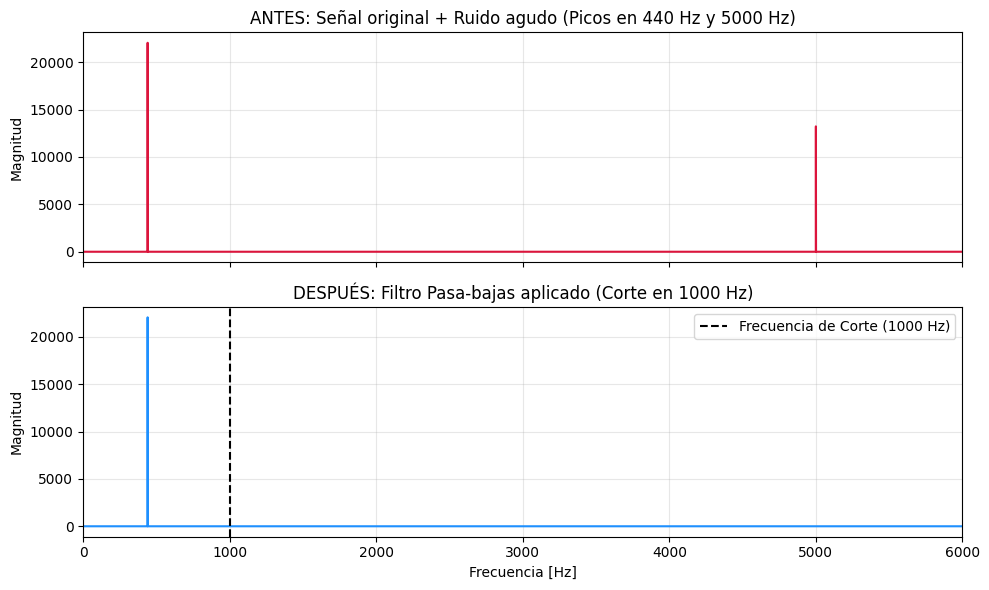

¡Prueba del filtro pasa-bajas completada!
Escucha los audios 'demo3_prueba_pasa_bajas_ruido.wav' y 'demo3_prueba_pasa_bajas_limpio.wav'


In [9]:
import sys
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from pathlib import Path

# 1. Importamos tu nuevo filtro
sys.path.append("..")
from src.filters import apply_lowpass_mask

# 2. CREAMOS EL ESCENARIO DE PRUEBA
sample_rate = 44100
duration = 2.0 # 2 segundos
t = np.arange(int(sample_rate * duration)) / sample_rate

# Nuestra señal útil (440 Hz - Frecuencia baja/media)
senal_util = 0.5 * np.sin(2 * np.pi * 440 * t)

# El ruido (5000 Hz - Frecuencia muy alta, como un siseo agudo)
ruido_agudo = 0.3 * np.sin(2 * np.pi * 5000 * t)

# Mezclamos ambas
senal_con_siseo = senal_util + ruido_agudo

# Guardamos el audio arruinado para escucharlo
ruta_siseo = Path("../data/processed/demo3_prueba_pasa_bajas_ruido.wav")
sf.write(ruta_siseo, senal_con_siseo, sample_rate)

# 3. APLICAMOS EL FILTRO PASA-BAJAS
N = len(senal_con_siseo)
frecuencias = fftfreq(N, 1 / sample_rate)

# Pasamos al dominio frecuencial
espectro_siseo = fft(senal_con_siseo)

# LA MAGIA: Aplicamos el filtro. "Corta todo lo que esté por encima de 1000 Hz"
espectro_limpio = apply_lowpass_mask(espectro_siseo, cutoff_hz=1000.0, sample_rate=sample_rate)

# Regresamos al tiempo
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
ruta_rescatada = Path("../data/processed/demo3_prueba_pasa_bajas_limpio.wav")
sf.write(ruta_rescatada, senal_rescatada, sample_rate)

# 4. VISUALIZACIÓN DE LA PRUEBA
mitad = N // 2
freqs_plot = frecuencias[:mitad]
mag_siseo = np.abs(espectro_siseo[:mitad])
mag_limpia = np.abs(espectro_limpio[:mitad])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(freqs_plot, mag_siseo, color='crimson')
ax1.set_title("ANTES: Señal original + Ruido agudo (Picos en 440 Hz y 5000 Hz)")
ax1.set_ylabel("Magnitud")
ax1.set_xlim(0, 6000) # Vemos hasta 6000 Hz para notar el ruido
ax1.grid(alpha=0.3)

ax2.plot(freqs_plot, mag_limpia, color='dodgerblue')
ax2.set_title("DESPUÉS: Filtro Pasa-bajas aplicado (Corte en 1000 Hz)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
# Dibujamos una línea vertical punteada para mostrar dónde pasó "la podadora"
ax2.axvline(x=1000, color='black', linestyle='--', label='Frecuencia de Corte (1000 Hz)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("¡Prueba del filtro pasa-bajas completada!")
print("Escucha los audios 'demo3_prueba_pasa_bajas_ruido.wav' y 'demo3_prueba_pasa_bajas_limpio.wav'")

---

## Demo 3: Filtro Pasa-Bajas

El filtro **pasa-bajas** deja pasar las frecuencias bajas y elimina todo lo que esté por encima de un punto de corte. Es como un portero que solo deja entrar a quienes tienen un número de membresía bajo.

**Escenario de esta prueba:**
- Señal útil: tono de **440 Hz** (frecuencia baja/media, como una nota musical).
- Ruido: siseo de **5,000 Hz** (frecuencia muy alta, como el ruido de una radio desintonizada).
- Punto de corte: **1,000 Hz** — todo lo que esté por encima de esa línea será eliminado.

La gráfica superior mostrará los dos picos (440 Hz y 5,000 Hz). La inferior demostrará que el pico de 5,000 Hz desapareció completamente.

➡️ En la gráfica: La gráfica superior (roja) mostrará claramente dos rascacielos: uno en 440 Hz y otro muy lejos a la derecha, en 5000 Hz. En la gráfica inferior (azul), verás una línea negra punteada en 1000 Hz. A partir de esa línea hacia la derecha, ¡absolutamente todo es un desierto plano (cero)! El pico de 5000 Hz fue erradicado.

Para probar el Filtro Pasa-bajas, necesitamos una señal que tenga exactamente lo que este filtro ataca: ruido de alta frecuencia (como el "siseo" de una radio desintonizada o el pitido de un mosquito).

Vamos a crear una prueba rápida donde generamos tu nota musical de 440 Hz (baja frecuencia) y le sumamos un pitido agudísimo y molesto de 5000 Hz (alta frecuencia). Luego, le pasaremos "la podadora" de tu filtro pasa-bajas para cortar todo lo que esté por encima de 1000 Hz.

# Prueba del Filtro Pasa-Altas

El filtro pasa-altas es el opuesto del pasa-bajas: **elimina las frecuencias bajas y conserva las altas**.

Es útil para eliminar:
- Zumbidos graves de fondo (como el ronroneo de un motor o vibraciones de baja frecuencia).
- Componentes DC (0 Hz) que desplazan la señal.
- Ruido de baja frecuencia en grabaciones ambientales.

En este experimento, creamos una señal útil de **3000 Hz** (aguda) y le sumamos un **rumble** grave de **300 Hz**. Luego aplicamos el filtro pasa-altas para eliminar el componente grave y conservar la señal útil.

> **¿Por qué 300 Hz y no 80 Hz?**
> El 80 Hz es tan grave que la mayoría de parlantes de laptop y auriculares básicos no lo reproducen físicamente. Con 300 Hz, el rumble es perfectamente audible en cualquier dispositivo y la diferencia entre el audio con ruido y el limpio es inmediata.

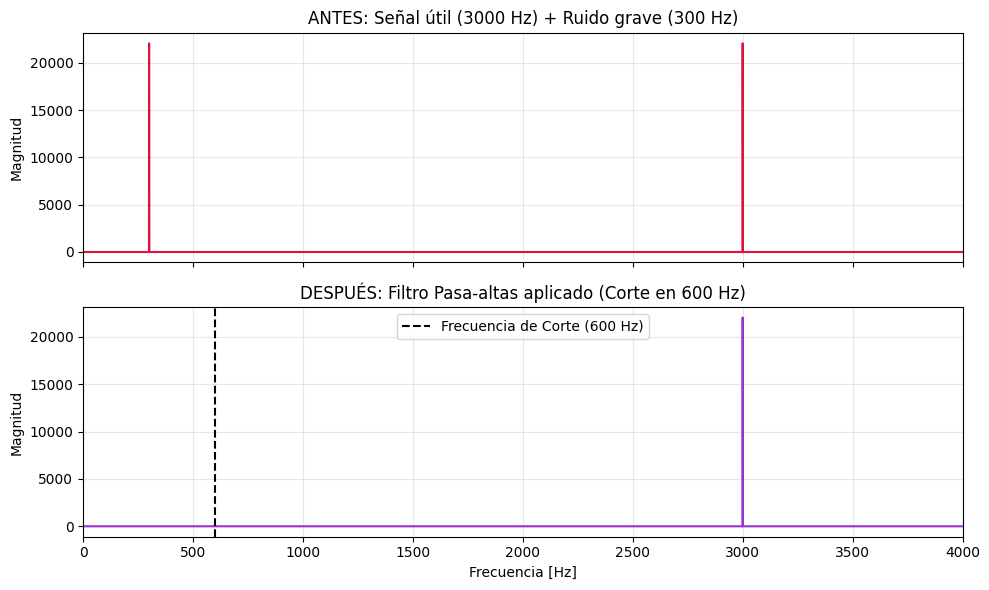

¡Prueba del filtro pasa-altas completada!
Escucha los audios 'demo4_prueba_pasa_altas_ruido.wav' y 'demo4_prueba_pasa_altas_limpio.wav'


In [10]:
import sys
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from pathlib import Path

sys.path.append("..")
from src.filters import apply_highpass_mask

# 1. CREAMOS EL ESCENARIO DE PRUEBA
sample_rate = 44100
duration = 2.0
t = np.arange(int(sample_rate * duration)) / sample_rate

# Señal útil: componente aguda de 3000 Hz
senal_util = 0.5 * np.sin(2 * np.pi * 3000 * t)

# Ruido grave: rumble de 300 Hz (audible en cualquier parlante o auricular)
ruido_grave = 0.5 * np.sin(2 * np.pi * 300 * t)

# Mezclamos ambas
senal_con_rumble = senal_util + ruido_grave

# Guardamos el audio con ruido
sf.write("../data/processed/demo4_prueba_pasa_altas_ruido.wav", senal_con_rumble, sample_rate)

# 2. APLICAMOS EL FILTRO PASA-ALTAS
N = len(senal_con_rumble)
espectro_rumble = fft(senal_con_rumble)

# Corta todo lo que esté por DEBAJO de 600 Hz (300 Hz queda fuera, 3000 Hz se conserva)
espectro_limpio = apply_highpass_mask(espectro_rumble, cutoff_hz=600.0, sample_rate=sample_rate)

# Regresamos al dominio temporal
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
sf.write("../data/processed/demo4_prueba_pasa_altas_limpio.wav", senal_rescatada, sample_rate)

# 3. VISUALIZACIÓN
mitad = N // 2
freqs_plot = fftfreq(N, 1 / sample_rate)[:mitad]
mag_rumble = np.abs(espectro_rumble[:mitad])
mag_limpia = np.abs(espectro_limpio[:mitad])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(freqs_plot, mag_rumble, color='crimson')
ax1.set_title("ANTES: Señal útil (3000 Hz) + Ruido grave (300 Hz)")
ax1.set_ylabel("Magnitud")
ax1.set_xlim(0, 4000)
ax1.grid(alpha=0.3)

ax2.plot(freqs_plot, mag_limpia, color='darkorchid')
ax2.set_title("DESPUÉS: Filtro Pasa-altas aplicado (Corte en 600 Hz)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
ax2.axvline(x=600, color='black', linestyle='--', label='Frecuencia de Corte (600 Hz)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("¡Prueba del filtro pasa-altas completada!")
print("Escucha los audios 'demo4_prueba_pasa_altas_ruido.wav' y 'demo4_prueba_pasa_altas_limpio.wav'")

# Final prueba arcaica